### 1. Load and Visualize the Time Series Data
We will use `yfinance` to get daily stock price data for this task.

/tmp/ipykernel_1017/387494237.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', start='2023-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed


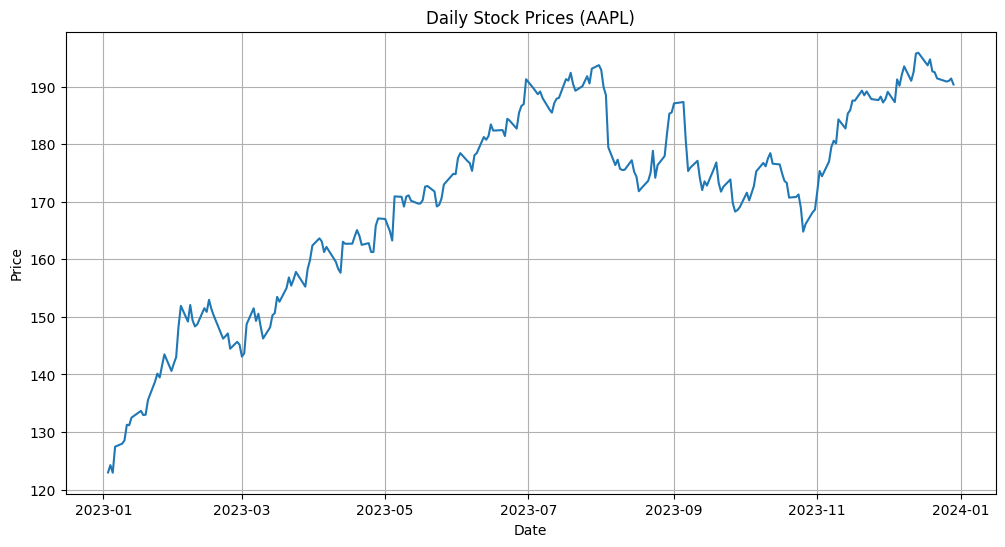

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error

# Load Daily Stock Data (e.g., Apple)
data = yf.download('AAPL', start='2023-01-01', end='2024-01-01')
df = data[['Close']].copy()
df.columns = ['Price']

# Visualize
plt.figure(figsize=(12, 6))
plt.plot(df['Price'])
plt.title('Daily Stock Prices (AAPL)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()

### 2 & 3. Test for Stationarity and Apply Differencing
We use the Augmented Dickey-Fuller (ADF) test. If p-value > 0.05, the series is non-stationary.

ADF Statistic: -2.5861211382426395
p-value: 0.09589980760585493
Is the series stationary? False


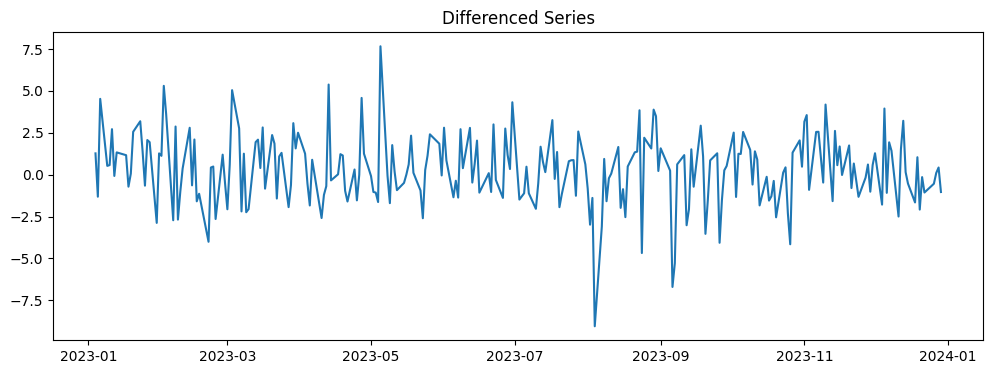

Stationarity after 1st differencing:
ADF Statistic: -14.748738068136324
p-value: 2.5042672457680724e-27


In [ ]:
def check_stationarity(series):
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    return result[1] <= 0.05

is_stationary = check_stationarity(df['Price'])
print(f"Is the series stationary? {is_stationary}")

# Apply differencing if non-stationary
if not is_stationary:
    df['Price_Diff'] = df['Price'].diff().dropna()
    plt.figure(figsize=(12, 4))
    plt.plot(df['Price_Diff'])
    plt.title('Differenced Series')
    plt.show()
    print("Stationarity after 1st differencing:")
    check_stationarity(df['Price_Diff'].dropna())

### 4. Decompose the Series
We decompose the series into trend, seasonal, and residual components.

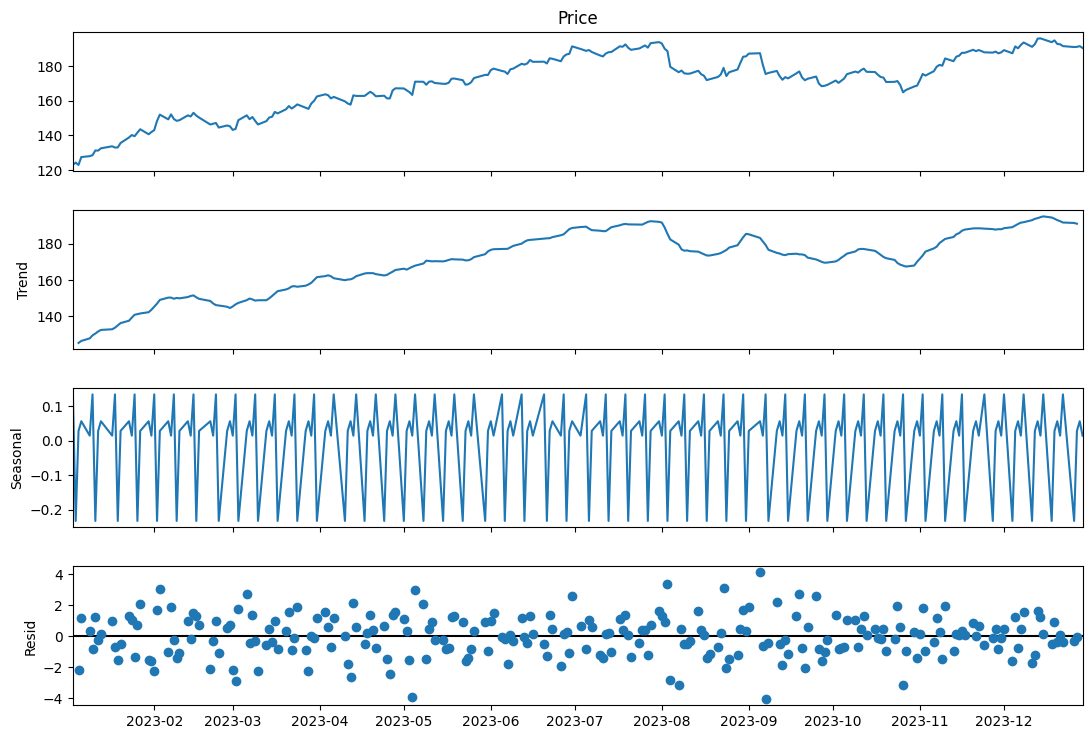

In [ ]:
decomposition = seasonal_decompose(df['Price'], model='additive', period=5) # 5 days for business week
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

### 5. Simple Moving Average (SMA)
Calculating moving averages with window sizes of 7 and 30 days.

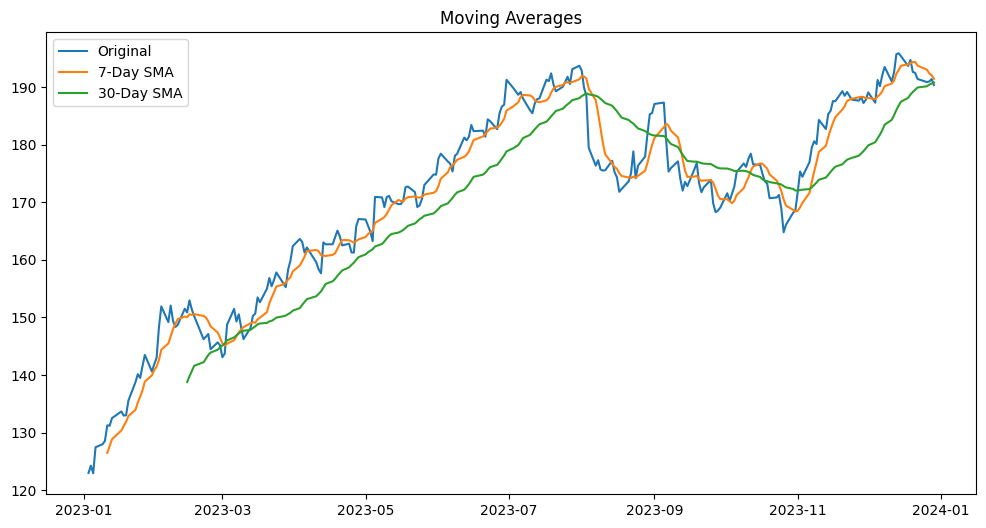

In [ ]:
df['SMA_7'] = df['Price'].rolling(window=7).mean()
df['SMA_30'] = df['Price'].rolling(window=30).mean()

plt.figure(figsize=(12, 6))
plt.plot(df['Price'], label='Original')
plt.plot(df['SMA_7'], label='7-Day SMA')
plt.plot(df['SMA_30'], label='30-Day SMA')
plt.legend()
plt.title('Moving Averages')
plt.show()

### 6 & 7. Forecast and Evaluate
We will hold out the last 7 days to calculate the Mean Absolute Error (MAE).

Naive Forecast MAE: 3.27
Moving Average Forecast MAE: 2.68


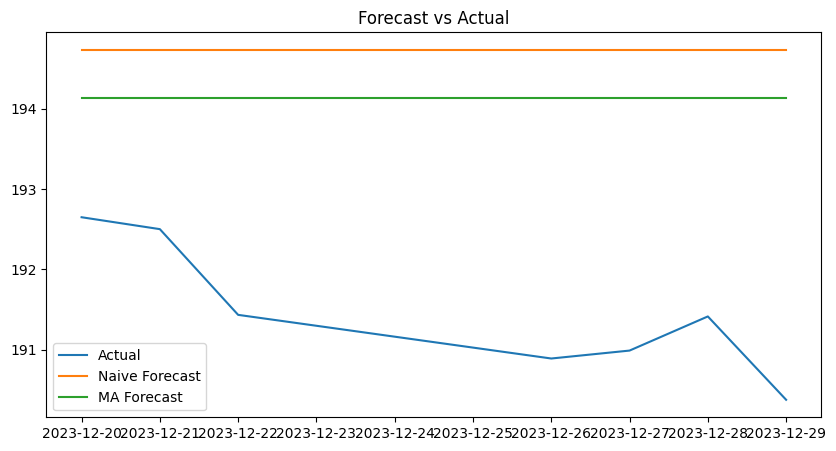

In [ ]:
train = df['Price'][:-7]
test = df['Price'][-7:]

# Naive Forecast (Last value)
naive_forecast = [train.iloc[-1]] * 7

# Moving Average Forecast (Last 7-day average)
ma_forecast = [train.rolling(window=7).mean().iloc[-1]] * 7

mae_naive = mean_absolute_error(test, naive_forecast)
mae_ma = mean_absolute_error(test, ma_forecast)

print(f"Naive Forecast MAE: {mae_naive:.2f}")
print(f"Moving Average Forecast MAE: {mae_ma:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, naive_forecast, label='Naive Forecast')
plt.plot(test.index, ma_forecast, label='MA Forecast')
plt.legend()
plt.title('Forecast vs Actual')
plt.show()